# 05 – Hyperparameter Tuning

This notebook applies systematic hyperparameter optimisation to the three baseline models from Notebook 04. The objective is to determine whether the performance of each model can be meaningfully improved through tuning, and to identify the best-performing traditional ML model before comparison with XGBoost in Notebook 06.

**Models tuned:**
1. Logistic Regression — GridSearchCV over regularisation strength and penalty type
2. Decision Tree — GridSearchCV over depth and leaf constraints to correct the unregularised baseline's overfitting
3. Random Forest — RandomizedSearchCV over the larger parameter space of tree count, depth, split constraints, and feature subsampling

**Method:** All searches use 5-fold stratified cross-validation, optimising for F1-score. Under-sampling is applied inside an `imblearn.Pipeline` at each fold to prevent data leakage from validation folds into the resampling step.

## Imports


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
    classification_report
)
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

BASE_DIR = Path("..").resolve()
PROCESSED_DIR = BASE_DIR / "data" / "processed"

## Load Processed Data

Preprocessed features and binary target labels loaded from Notebook 02 outputs.

In [2]:
X = pd.read_csv(PROCESSED_DIR / "cell2celltrain_processed.csv")
y = pd.read_csv(PROCESSED_DIR / "cell2celltrain_target.csv").squeeze("columns")

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (51047, 50)
Target shape: (51047,)


## Train-Test Split

80/20 stratified split (`random_state=42`), consistent with Notebooks 03–04.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:    ", X_test.shape)

Training set size: (40837, 50)
Test set size:     (10210, 50)


## Leakage-Free Resampling via Pipeline Integration

A critical methodological change from Notebook 04 is introduced here: rather than applying under-sampling once before cross-validation begins, under-sampling is wrapped inside an `imblearn.Pipeline` alongside each model. During `GridSearchCV` and `RandomizedSearchCV`, `scikit-learn` calls `pipeline.fit()` on the training fold and `pipeline.predict()` on the validation fold for each CV split. Because `RandomUnderSampler` is a pipeline step, it is applied only within each training fold — the validation fold always retains the original class distribution.

This is essential for unbiased CV scoring: if resampling were applied globally before cross-validation, the validation fold would contain artificially balanced data that does not reflect real-world conditions, inflating the reported F1 scores.

In [4]:
# Under-sampling is now handled inside each model's ImbPipeline — no standalone resampling step needed.
print("Under-sampling will be applied within each CV fold via ImbPipeline.")

Under-sampling will be applied within each CV fold via ImbPipeline.


## Evaluation Function

Same function as Notebook 04 — ensures metrics are computed consistently across all experiments.

In [5]:
def evaluate_model(name, model, X_test, y_test):
    """Evaluate a fitted classifier and print a formatted results summary."""
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall    = recall_score(y_test, y_pred, zero_division=0)
    f1        = f1_score(y_test, y_pred, zero_division=0)
    roc_auc   = roc_auc_score(y_test, y_prob)
    cm        = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"=== {name} ===")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1-score  : {f1:.4f}")
    print(f"  ROC-AUC   : {roc_auc:.4f}")
    print(f"  Confusion Matrix:")
    print(f"    TN={tn}  FP={fp}")
    print(f"    FN={fn}  TP={tp}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"], zero_division=0))

    return {
        "Precision": round(precision, 4),
        "Recall":    round(recall, 4),
        "F1-score":  round(f1, 4),
        "ROC-AUC":   round(roc_auc, 4),
        "Confusion Matrix": cm
    }

## Model 1 — Logistic Regression Tuning

GridSearchCV over regularisation strength (`C`) and penalty type (`l1`/`l2`). `solver='liblinear'` required for L1 support. Scoring metric: F1.


In [6]:
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_lr = ImbPipeline([
    ("undersample", RandomUnderSampler(random_state=42)),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

param_grid_lr = {
    "model__C":       [0.01, 0.1, 1.0, 10.0, 100.0],
    "model__penalty": ["l1", "l2"],
    "model__solver":  ["liblinear"]
}

search_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)
search_lr.fit(X_train, y_train)

print("Best params:", search_lr.best_params_)
print("Best CV F1: ", round(search_lr.best_score_, 4))
results["Logistic Regression (Tuned)"] = evaluate_model(
    "Logistic Regression (Tuned)", search_lr.best_estimator_, X_test, y_test
)

Best params: {'model__C': 0.1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV F1:  0.4453
=== Logistic Regression (Tuned) ===
  Precision : 0.3599
  Recall    : 0.5744
  F1-score  : 0.4425
  ROC-AUC   : 0.6122
  Confusion Matrix:
    TN=4262  FP=3006
    FN=1252  TP=1690

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.77      0.59      0.67      7268
       Churn       0.36      0.57      0.44      2942

    accuracy                           0.58     10210
   macro avg       0.57      0.58      0.55     10210
weighted avg       0.65      0.58      0.60     10210



Tuning Logistic Regression produced marginal improvement: F1 changed from 0.4434 to 0.4425 and ROC-AUC from 0.6117 to 0.6122. The best parameters selected L1 regularisation with `C=0.1` — a slightly stronger regularisation than the default — confirming that the model's performance ceiling is determined by its linear decision boundary, not by regularisation choices. The near-identical results across all candidate `C` values indicate that this feature space is inherently non-linearly separable and that no amount of regularisation tuning can overcome a fundamental architectural limitation.

## Model 2 — Decision Tree Tuning

GridSearchCV over depth and leaf constraints (`max_depth`, `min_samples_split`, `min_samples_leaf`). Addresses the overfitting seen in Notebook 04.


In [7]:
pipe_dt = ImbPipeline([
    ("undersample", RandomUnderSampler(random_state=42)),
    ("model", DecisionTreeClassifier(random_state=42))
])

param_grid_dt = {
    "model__max_depth":         [3, 5, 7, 10, 15, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf":  [1, 2, 5, 10]
}

search_dt = GridSearchCV(
    estimator=pipe_dt,
    param_grid=param_grid_dt,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)
search_dt.fit(X_train, y_train)

print("Best params:", search_dt.best_params_)
print("Best CV F1: ", round(search_dt.best_score_, 4))
results["Decision Tree (Tuned)"] = evaluate_model(
    "Decision Tree (Tuned)", search_dt.best_estimator_, X_test, y_test
)

Best params: {'model__max_depth': 5, 'model__min_samples_leaf': 5, 'model__min_samples_split': 20}
Best CV F1:  0.4779
=== Decision Tree (Tuned) ===
  Precision : 0.3756
  Recall    : 0.5421
  F1-score  : 0.4437
  ROC-AUC   : 0.6243
  Confusion Matrix:
    TN=4616  FP=2652
    FN=1347  TP=1595

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.77      0.64      0.70      7268
       Churn       0.38      0.54      0.44      2942

    accuracy                           0.61     10210
   macro avg       0.57      0.59      0.57     10210
weighted avg       0.66      0.61      0.62     10210



Depth constraints substantially corrected the Decision Tree's overfitting. Capping `max_depth` at 5 improved F1 from 0.4128 to 0.4437 and ROC-AUC from 0.5502 to 0.6243 — the latter now well above random chance. Precision improved markedly (0.332 → 0.376), indicating fewer false positives, whilst recall fell slightly (0.547 → 0.542 — marginal and within noise). The constrained tree has learned a more generalisable decision boundary rather than memorising training data. This result confirms that the unregularised baseline's poor performance was attributable to the absence of depth constraints rather than to any inherent weakness of the tree architecture itself.

## Model 3 — Random Forest Tuning

RandomizedSearchCV (20 iterations, 5-fold CV) over tree count, depth, split constraints, and feature subsampling. Randomised search is used due to the larger parameter space.


In [8]:
pipe_rf = ImbPipeline([
    ("undersample", RandomUnderSampler(random_state=42)),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_dist_rf = {
    "model__n_estimators":      [100, 200, 300],
    "model__max_depth":         [3, 5, 7, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__max_features":      ["sqrt", "log2", 0.3, 0.5]
}

search_rf = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search_rf.fit(X_train, y_train)

print("Best params:", search_rf.best_params_)
print("Best CV F1: ", round(search_rf.best_score_, 4))
results["Random Forest (Tuned)"] = evaluate_model(
    "Random Forest (Tuned)", search_rf.best_estimator_, X_test, y_test
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__max_features': 0.5, 'model__max_depth': 10}
Best CV F1:  0.4933
=== Random Forest (Tuned) ===
  Precision : 0.3763
  Recall    : 0.6917
  F1-score  : 0.4874
  ROC-AUC   : 0.6576
  Confusion Matrix:
    TN=3895  FP=3373
    FN=907  TP=2035

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.81      0.54      0.65      7268
       Churn       0.38      0.69      0.49      2942

    accuracy                           0.58     10210
   macro avg       0.59      0.61      0.57     10210
weighted avg       0.69      0.58      0.60     10210



Tuning Random Forest produced the most significant improvement of the three models. F1 increased from 0.4784 to 0.4874 and ROC-AUC from 0.6542 to 0.6576. The largest gain was in recall (0.626 → 0.692), meaning the tuned model identified 2,035 churners compared to 1,842 for the default — 193 additional churners correctly flagged. The selected configuration (`n_estimators=200`, `max_depth=10`, `min_samples_split=10`, `max_features=0.5`) applies stronger feature subsampling than the default (`sqrt` ≈ 0.14 of features), allowing each tree to consider a richer set of features at each split and improving overall discriminative power. The 20-iteration randomised search is a pragmatic choice given the large parameter space; a full grid search would be computationally prohibitive.

## Tuned Model Comparison


In [9]:
summary = pd.DataFrame(
    {
        name: {m: metrics[m] for m in ["Precision", "Recall", "F1-score", "ROC-AUC"]}
        for name, metrics in results.items()
    }
).T

print("=== Tuned Model Comparison ===")
print(summary.to_string())

summary.to_csv(PROCESSED_DIR / "notebook05_tuned_results.csv")
print("\nResults saved to:", PROCESSED_DIR / "notebook05_tuned_results.csv")

=== Tuned Model Comparison ===
                             Precision  Recall  F1-score  ROC-AUC
Logistic Regression (Tuned)     0.3599  0.5744    0.4425   0.6122
Decision Tree (Tuned)           0.3756  0.5421    0.4437   0.6243
Random Forest (Tuned)           0.3763  0.6917    0.4874   0.6576

Results saved to: /Users/abbasq/Uni/third-year/IP/data/processed/notebook05_tuned_results.csv


## Confusion Matrices

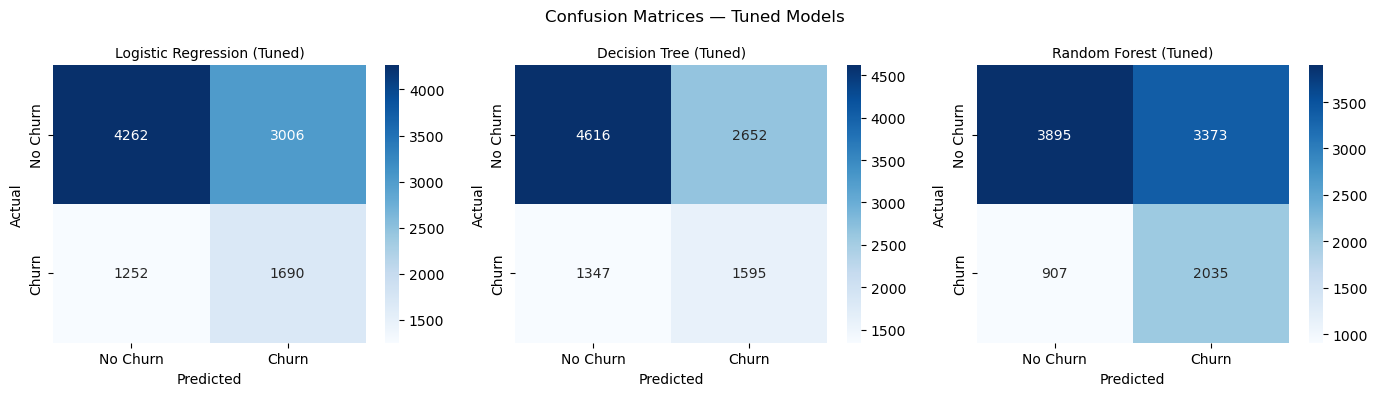

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, metrics) in zip(axes, results.items()):
    cm = metrics["Confusion Matrix"]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=["No Churn", "Churn"],
                yticklabels=["No Churn", "Churn"])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — Tuned Models", fontsize=12)
plt.tight_layout()
plt.show()

## Key Observations and Model Selection

Three clear patterns emerge from this comparison:

- **Logistic Regression** is insensitive to tuning because its performance is bounded by its linear architecture. The feature space is non-linearly separable, and regularisation parameter choices do not change this fundamental constraint.
- **Decision Tree** shows the largest relative improvement from tuning (+0.031 F1, +0.074 ROC-AUC) because the unregularised baseline was severely overfitting. Depth constraints effectively regularise the model, bringing its performance in line with — and slightly above — Logistic Regression.
- **Random Forest (Tuned)** is the best-performing model across all four metrics, with the highest recall (0.692) reflecting 2,035 churners correctly identified. The tuning gain (+0.009 F1, +0.003 ROC-AUC) is modest but consistent.

**Random Forest (Tuned) is the best traditional ML model** and is carried forward as the benchmark for comparison against XGBoost in Notebook 06. The comparison will determine whether gradient boosting provides a further architectural advantage over the best-tuned ensemble classifier.